In [14]:
# General imports
import pickle
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Sklearn imports
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [15]:
# Convert 1D array to 2D array
def convert(array):
    length = len(array)
    new_shape = (length, 1)
    array = np.reshape(array, new_shape)
    return array

In [16]:
# Depickle: Training
TRAINING_FILE = open('data/train.pkl', 'rb')
train_data = pickle.load(TRAINING_FILE)

# Depickle: Testing
TESTING_FILE = open('data/test.pkl', 'rb')
test_data = pickle.load(TESTING_FILE)

In [17]:
# Extract arrays and convert to 2D

# Train: Feature
X_train = train_data[:, 0]
X_train = convert(X_train)

# Train: Label
Y_train = train_data[:, 1]
Y_train = convert(Y_train)
         
# Test: Feature
X_test = test_data[:, 0]
X_test = convert(X_test)

# Test: Label
Y_test = test_data[:, 1]
Y_test = convert(Y_test)

In [18]:
# Display training and testing data
print(train_data.shape)
print(test_data.shape)
print()

print(train_data[:3])
print()
print(test_data[:3])

(8000, 2)
(80, 2)

[[  27.42765666 3335.78295109]
 [  -4.96183456 2647.40265244]
 [ -27.86119551  520.73369536]]

[[  -15.029       -351.99223091]
 [  -25.977      -1807.03436449]
 [   -4.48          -9.00368   ]]


In [19]:
# Definitions
GRAPH_SIZE = (20, 10)
NUM_DATASETS = 16
TOTAL_SIZE = len(train_data)
DATASET_SIZE = int(TOTAL_SIZE/NUM_DATASETS)
MIN_ORDER = 1
MAX_ORDER = 16

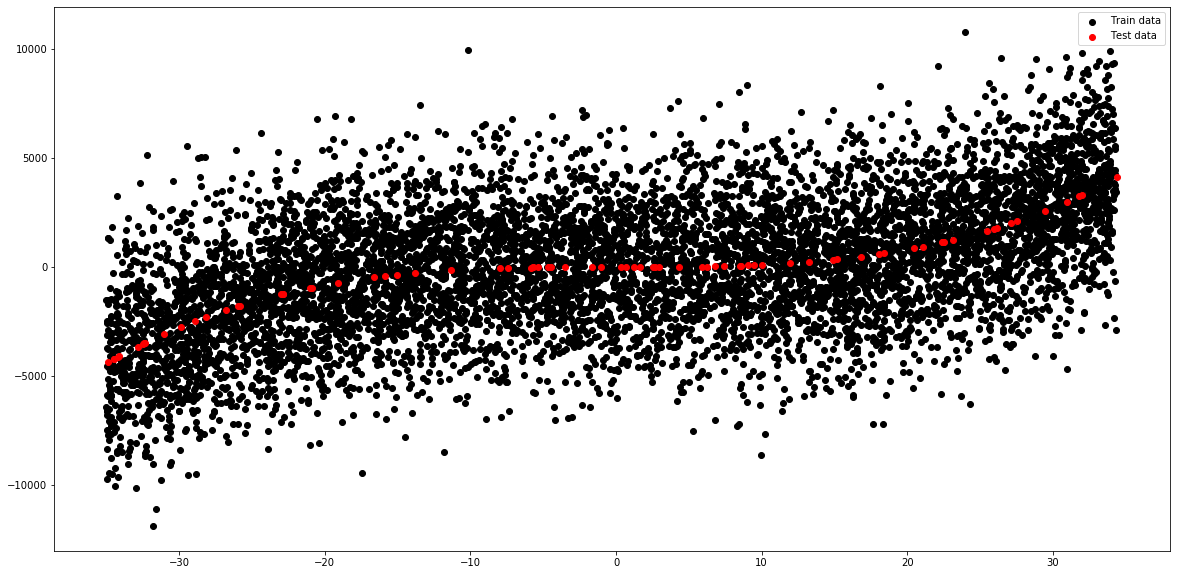

In [20]:
# Plot the graph
plt.figure(figsize=GRAPH_SIZE)

plt.scatter(X_train, Y_train, label="Train data", color='black')
plt.scatter(X_test , Y_test,  label="Test data" , color='red')

plt.legend()
plt.show()

In [21]:
# Separate the dataset
np.random.shuffle(train_data)
test_data = np.sort(test_data, axis = 0)
train_sets = []
for i in range(NUM_DATASETS):
    train_sets.append(train_data[500*i : 500*(i+1)])
print(train_sets[0])

[[ 3.24254326e+01  3.32077357e+03]
 [-1.85170399e+01 -1.04955391e+02]
 [ 2.20670100e+01 -8.06235207e+01]
 [ 1.09846063e+01 -7.31332683e+02]
 [-2.33949429e+01 -4.32146558e+03]
 [-1.04903824e+01  5.22022983e+02]
 [ 2.42002398e+01  1.44665625e+03]
 [-1.70469890e+00  4.10476061e+03]
 [-4.85802990e+00  1.87332346e+03]
 [ 2.61864721e+01  1.34444115e+03]
 [-1.52788753e+01  1.22711994e+03]
 [ 8.06518078e+00  1.94793674e+03]
 [-1.86709286e+01 -2.28752669e+03]
 [ 2.38666201e+01  2.56867544e+03]
 [-2.86944761e+01 -2.95389494e+03]
 [ 2.17715616e+01  8.53962185e+01]
 [-8.84616508e+00 -2.44555443e+03]
 [-2.44446486e+01 -3.48076073e+03]
 [-3.30380389e+01  8.84479521e+02]
 [-1.70726868e+01  5.86660596e+02]
 [ 1.90258331e+01  3.08698642e+02]
 [-2.93844337e+01  1.24326949e+03]
 [ 2.82984897e+01  1.72561905e+03]
 [ 1.63829920e+00  3.64067274e+01]
 [ 2.20831556e+01  2.33267164e+02]
 [-4.73256419e+00 -2.20344212e+03]
 [ 2.52629895e+01  6.25907231e+03]
 [ 1.63489702e+01  2.72549700e+03]
 [-9.40410367e+00 -1

In [22]:
# Train the models
models = [[]]
polies = [[]]
for order in range(MIN_ORDER, MAX_ORDER):
    models.append([])
    polies.append([])
    
    for train_set in train_sets:
        poly = PolynomialFeatures(order)
        
        x_train = train_set[:, 0]
        size = (len(x_train), 1)
        x_train = np.reshape(x_train, size)
        
        y_train = train_set[:, 1]
        size = (len(y_train), 1)
        y_train = np.reshape(y_train, size)
        
        x_train = poly.fit_transform(x_train)
        
        regmodel = LinearRegression().fit(x_train, y_train)
        
        models[order].append(regmodel)
        polies[order].append(poly)

In [23]:
# Obtain the predictions from each model
predictions = [[]]
for order in range(MIN_ORDER, MAX_ORDER):
    predictions.append([])
    
    for i in range(16):
        x_test = test_data[:,0]
        shape = (len(x_test), 1)
        x_test = np.reshape(x_test, shape)
        
        x_test = polies[order][i].transform(x_test)
        
        predictions[order].append(models[order][i].predict(x_test))

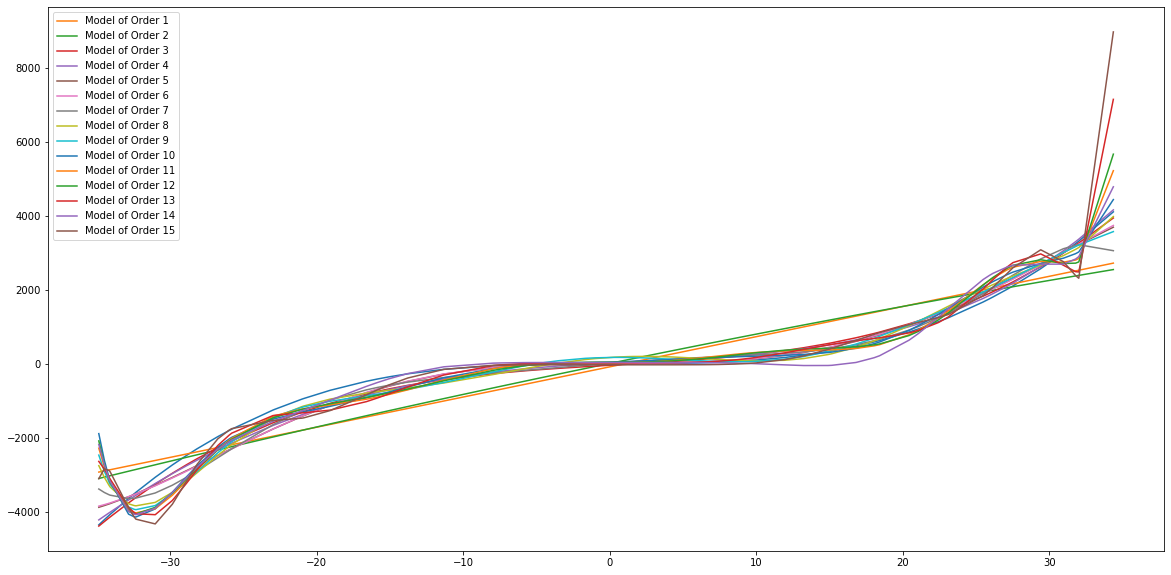

In [26]:
# Plotting one of every polynomial class
plt.figure(figsize=GRAPH_SIZE)
plt.scatter(np.split(test_data, 2, axis = 1)[0], np.split(test_data, 2, axis = 1)[1])
for order in range(MIN_ORDER, MAX_ORDER):
    for train_set in range(1):
        
        x_test = test_data[:,0]
        shape = (len(x_test), 1)
        x_test = np.reshape(x_test, shape)
        
        plt.plot(x_test, predictions[order][train_set], label='Model of Order '+str(order))
plt.legend()